<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/CNN_MNIST_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN for MNIST

Simple Keras CNN from the *Convolutional Neural Networks* MSE presentation (CHRIST University, slide 7). Runs as is in Google Colab; a GPU runtime speeds up training but is not required.

In [1]:
import keras
from keras import layers

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr[..., None].astype("float32") / 255.0  # (60000,28,28,1)
x_te = x_te[..., None].astype("float32") / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"),  # 26x26x32
    layers.MaxPooling2D(2),                    # 13x13x32
    layers.Conv2D(64, 3, activation="relu"),  # 11x11x64
    layers.MaxPooling2D(2),                    # 5x5x64
    layers.Flatten(),                          # 1600
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(x_tr, y_tr, batch_size=128, epochs=10,
                     validation_split=0.1)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 103ms/step - accuracy: 0.8928 - loss: 0.3557 - val_accuracy: 0.9777 - val_loss: 0.0850
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9664 - loss: 0.1092 - val_accuracy: 0.9862 - val_loss: 0.0530
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9740 - loss: 0.0855 - val_accuracy: 0.9875 - val_loss: 0.0458
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 96ms/step - accuracy: 0.9769 - loss: 0.0728 - val_accuracy: 0.9887 - val_loss: 0.0413
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9801 - loss: 0.0636 - val_accuracy: 0.9893 - val_loss: 0.0392
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9824 - loss: 0.0573 - val_accuracy: 0.9898 - val_loss: 0.0369
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9834 - loss: 0.0541 - val_accuracy: 0.9908 - val_loss: 0.0331
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9839 - loss: 0.0493 

In [4]:
print(model.evaluate(x_te, y_te, verbose=0))  # [loss, acc]


[0.028520336374640465, 0.9902999997138977]


##Training curves (slide 8)

Uses the `history` object returned by `model.fit` above, no extra training needed.

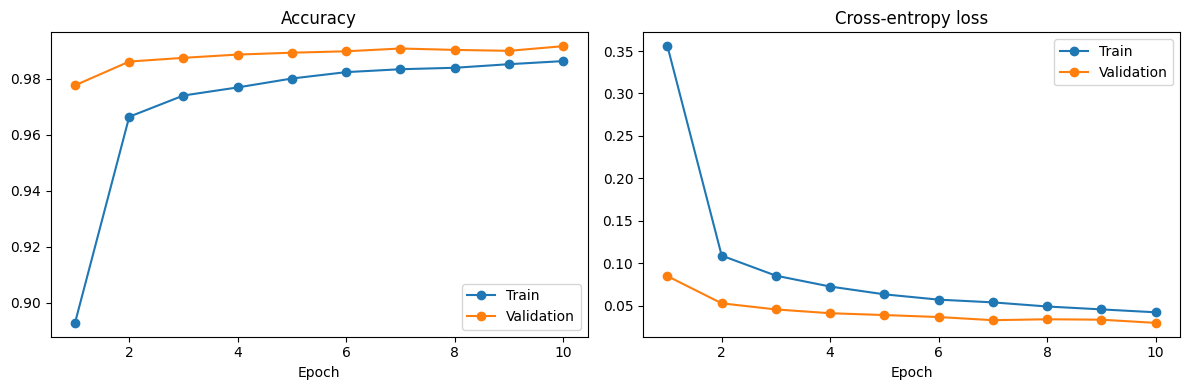

In [5]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, acc, marker="o", label="Train")
axes[0].plot(epochs_range, val_acc, marker="o", label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, loss, marker="o", label="Train")
axes[1].plot(epochs_range, val_loss, marker="o", label="Validation")
axes[1].set_title("Cross-entropy loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()
